# Challenge TelecomX - Análisis de Evasión de Clientes
Por Ana Berenice Noriega Camacho




## Introducción

Este es el desafío número dos de la preparación como Data Scientist en el programa Oracle Next Education (ONE) de Oracle en colaboración con Alura LATAM.

Para este desafío, suponemos que hemos sido contratados como asistente de análisis de datos en Telecom X, y formamos parte del proyecto "Churn de Clientes". La empresa enfrenta una alta tasa de cancelaciones (churn) y necesita comprender los factores que llevan a la pérdida de clientes.

Nuestro desafío es recopilar, procesar y analizar los datos, utilizando Python y sus principales bibliotecas para extraer información valiosa. A partir de nuestro análisis, el equipo de Data Science podrá avanzar en modelos predictivos y desarrollar estrategias para reducir la evasión.


#### ¿Qué practicamos en este desafío?


✅ Importar y manipular datos desde una API de manera eficiente.

✅ Aplicar los conceptos de ETL (Extracción, Transformación y Carga) en la preparación de los datos.

✅ Crear visualizaciones estratégicas para identificar patrones y tendencias.


✅ Realizar un Análisis Exploratorio de Datos (EDA) y generar un informe con insights relevantes.


##📌 Importación de datos

Extraemos el archivo json, pero nos damos cuenta que tiene diccionarios anidados, por lo que hay que proceder a normalizar el archivo.

In [1]:
import pandas as pd

data_inicial= pd.read_json("TelecomX_Data.json")
data_inicial

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
...,...,...,...,...,...,...
7262,9987-LUTYD,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
7263,9992-RRAMN,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7264,9992-UJOEL,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
7265,9993-LHIEB,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Two year', 'PaperlessBilling': '..."


## Normalización del archivo json

Como son varias las columnas con diccionarios anidados, las normalizaré por separado y posteriormente las uniré en un mismo dataframe

In [2]:
customer_df = pd.json_normalize(data_inicial["customer"])
phone_df = pd.json_normalize(data_inicial["phone"])
internet_df = pd.json_normalize(data_inicial["internet"])
account_df = pd.json_normalize(data_inicial["account"])

In [3]:
data = pd.concat(
    [data_inicial.drop(columns=["customer","phone","internet","account"]),
     customer_df,
     phone_df,
     internet_df,
     account_df],
    axis=1
)
data.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


## Exploración de los datos

In [4]:
#Veo las características principales de mis datos.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [5]:
#Veo qué valores contiene cada una de las columnas
for col in data.columns:
    print(f"\n--- {col} ---")
    print(pd.unique(data[col]))


--- customerID ---
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

--- Churn ---
['No' 'Yes' '']

--- gender ---
['Female' 'Male']

--- SeniorCitizen ---
[0 1]

--- Partner ---
['Yes' 'No']

--- Dependents ---
['Yes' 'No']

--- tenure ---
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

--- PhoneService ---
['Yes' 'No']

--- MultipleLines ---
['No' 'Yes' 'No phone service']

--- InternetService ---
['DSL' 'Fiber optic' 'No']

--- OnlineSecurity ---
['No' 'Yes' 'No internet service']

--- OnlineBackup ---
['Yes' 'No' 'No internet service']

--- DeviceProtection ---
['No' 'Yes' 'No internet service']

--- TechSupport ---
['Yes' 'No' 'No internet service']

--- StreamingTV ---
['Yes' 'No' 'No internet service']

--- StreamingMovies ---
['No' 'Yes' 'No internet service']

--- Co

In [6]:
#Veo la estructura de mis datos
data.shape

(7267, 21)

##🔧 Transformación de los datos

In [7]:
#Convertir Charges.Total a numérico

In [8]:
#Había valores de strings vacíos así que los reemplacé por 0
data[data["Charges.Total"] == " "]
data["Charges.Total"] = data["Charges.Total"].replace(" ", 0)

In [9]:
#Luego ya los convierto a numérico
data["Charges.Total"] = pd.to_numeric(data["Charges.Total"])

In [10]:
#verificamos si hay datos duplicados
data.duplicated().sum()

np.int64(0)

In [11]:
#Ahora binarizo nuestra columna de interés, que es Churn o cancelación
binarizables = ["Churn"]
for i in binarizables:
  data[i] = data[i].map({"Yes": 1, "No": 0})

In [12]:
#me dio error así que primero veo cuántos valores nan hay en todos los datos depues de esta transformacion
for col in data.columns:
    print(f"\n--- {col} ---")
    print(data[col].isna().sum())

#me di cuent que es porque hay Churn con valores vacíos: " "



--- customerID ---
0

--- Churn ---
224

--- gender ---
0

--- SeniorCitizen ---
0

--- Partner ---
0

--- Dependents ---
0

--- tenure ---
0

--- PhoneService ---
0

--- MultipleLines ---
0

--- InternetService ---
0

--- OnlineSecurity ---
0

--- OnlineBackup ---
0

--- DeviceProtection ---
0

--- TechSupport ---
0

--- StreamingTV ---
0

--- StreamingMovies ---
0

--- Contract ---
0

--- PaperlessBilling ---
0

--- PaymentMethod ---
0

--- Charges.Monthly ---
0

--- Charges.Total ---
0


In [13]:
#elimino los 224 registros nan de Churn, que solo representan un 3% de mis datos
data = data.dropna(subset=["Churn"]).copy()

In [14]:
#y ahora sí convierto los churn a int
data["Churn"]= data["Churn"].astype(int)

In [15]:
#Categorizo las columna de Senior Citizen que está binarizada, porque la quiero considerar como categoría en futuros procesos de este notebook
categorizables = ["SeniorCitizen"]
for i in categorizables:
  data[i] = data[i].map({1: "Yes", 0: "No"})

In [16]:
#verifico cómo se ven ahora mis datos
data.head(5)

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,0,Female,No,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,0,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,1,Male,No,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,1,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [17]:
#verifico la información de mis datos
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   int64  
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

In [18]:
#Generamos una columna de cuentas diarias
#Usamos un aproximado de 30 días por mes

data["Cuentas_Diarias"] = (data["Charges.Monthly"] / 30).round(2)

In [19]:
#verifico que se haya creado correctamente
data.columns

Index(['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total',
       'Cuentas_Diarias'],
      dtype='object')

### Preparación de los datos para graficación

Para promover la claridad y comunicación de los resultados, facilitando la interpretación y evitando confusiones, especialmente al compartir información con stakeholders no técnicos.

In [20]:
#genero un nuevo data frame con los nombres traducidos de todo para que sea fácil de graficar.
data_plot = data.copy()

In [21]:
traducciones = {

    "Churn": {
        1: "Canceló",
        0: "No canceló"
    },

    "SeniorCitizen": {
        "Yes": "Sí",
        "No": "No"
    },

    "gender": {
        "Male": "Hombre",
        "Female": "Mujer"
    },

    "Partner": {
        "Yes": "Sí",
        "No": "No"
    },

    "Dependents": {
        "Yes": "Sí",
        "No": "No"
    },

    "PhoneService": {
        "Yes": "Sí",
        "No": "No"
    },

    "MultipleLines": {
        "Yes": "Sí",
        "No": "No",
        "No phone service": "Sin servicio telefónico"
    },

    "InternetService": {
        "DSL": "DSL",
        "Fiber optic": "Fibra óptica",
        "No": "Sin internet"
    },

    "OnlineSecurity": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "OnlineBackup": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "DeviceProtection": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "TechSupport": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "StreamingTV": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "StreamingMovies": {
        "Yes": "Sí",
        "No": "No",
        "No internet service": "Sin internet"
    },

    "Contract": {
        "Month-to-month": "Mes a mes",
        "One year": "Un año",
        "Two year": "Dos años"
    },

    "PaperlessBilling": {
        "Yes": "Sí",
        "No": "No"
    },

    "PaymentMethod": {
        "Electronic check": "Cheque electrónico",
        "Mailed check": "Cheque por correo",
        "Bank transfer (automatic)": "Transferencia bancaria automática",
        "Credit card (automatic)": "Tarjeta de crédito automática"
    }
}

data_plot.replace(traducciones, inplace=True)

In [22]:
data_plot = data_plot.rename(columns={
    "customerID": "ID_cliente",
    "Churn": "Cancelación",
    "gender": "Género",
    "SeniorCitizen": "Cliente Adulto mayor",
    "Partner": "Cliente con pareja",
    "Dependents": "Cliente con dependientes",
    "tenure": "Antigüedad (meses)",
    "PhoneService": "Servicio telefónico",
    "MultipleLines": "Múltiples líneas",
    "InternetService": "Servicio de internet",
    "OnlineSecurity": "Seguridad en línea",
    "OnlineBackup": "Respaldo en línea",
    "DeviceProtection": "Protección de dispositivo",
    "TechSupport": "Soporte técnico",
    "StreamingTV": "Streaming TV",
    "StreamingMovies": "Streaming películas",
    "Contract": "Tipo de contrato",
    "PaperlessBilling": "Facturación sin papel",
    "PaymentMethod": "Método de pago",
    "Charges.Monthly": "Cargo mensual",
    "Charges.Total": "Cargo total",
    "Cuentas_Diarias": "Cuentas diarias"
})

In [23]:
data_plot

,ID_cliente,Cancelación,Género,Cliente Adulto mayor,Cliente con pareja,Cliente con dependientes,Antigüedad (meses),Servicio telefónico,Múltiples líneas,Servicio de internet,...,Protección de dispositivo,Soporte técnico,Streaming TV,Streaming películas,Tipo de contrato,Facturación sin papel,Método de pago,Cargo mensual,Cargo total,Cuentas diarias
0,0002-ORFBO,No canceló,Mujer,No,Sí,Sí,9,Sí,No,DSL,...,No,Sí,Sí,No,Un año,Sí,Cheque por correo,65.60,593.30,2.19
1,0003-MKNFE,No canceló,Hombre,No,No,No,9,Sí,Sí,DSL,...,No,No,No,Sí,Mes a mes,No,Cheque por correo,59.90,542.40,2.00
2,0004-TLHLJ,Canceló,Hombre,No,No,No,4,Sí,No,Fibra óptica,...,Sí,No,No,No,Mes a mes,Sí,Cheque electrónico,73.90,280.85,2.46
3,0011-IGKFF,Canceló,Hombre,Sí,Sí,No,13,Sí,No,Fibra óptica,...,Sí,No,Sí,Sí,Mes a mes,Sí,Cheque electrónico,98.00,1237.85,3.27
4,0013-EXCHZ,Canceló,Mujer,Sí,Sí,No,3,Sí,No,Fibra óptica,...,No,Sí,Sí,No,Mes a mes,Sí,Cheque por correo,83.90,267.40,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No canceló,Mujer,No,No,No,13,Sí,No,DSL,...,No,Sí,No,No,Un año,No,Cheque por correo,55.15,742.90,1.84
7263,9992-RRAMN,Canceló,Hombre,No,Sí,No,22,Sí,Sí,Fibra óptica,...,No,No,No,Sí,Mes a mes,Sí,Cheque electrónico,85.10,1873.70,2.84
7264,9992-UJOEL,No canceló,Hombre,No,No,No,2,Sí,No,DSL,...,No,No,No,No,Mes a mes,Sí,Cheque por correo,50.30,92.75,1.68
7265,9993-LHIEB,No canceló,Hombre,No,Sí,Sí,67,Sí,No,DSL,...,Sí,Sí,No,Sí,Dos años,No,Cheque por correo,67.85,4627.65,2.26


Guardo mis datos limpios para su posterior uso

In [24]:
datos_limpios_csv= data.to_csv("/content/drive/MyDrive/OracleONE/Challenges/2-TelecomX/TelecomX_Data_Limpia.csv", index= False)
datos_limpios_csv

In [25]:
data_plot_csv= data_plot.to_csv("/content/drive/MyDrive/OracleONE/Challenges/2-TelecomX/TelecomX_Data_plot.csv", index= False)
data_plot_csv

##📊 Análisis exploratorio de los datos

### Características de mis clientes

Primero conozcamos a nuestros clientes.

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Variables a visualizar
categoricas = ["Género", "Cliente Adulto mayor", "Cliente con pareja", "Cliente con dependientes"]

fig = make_subplots(
    rows=2, cols=2, specs=[[{'type':'domain'}, {'type':'domain'}],
                            [{'type':'domain'}, {'type':'domain'}]],
    subplot_titles=categoricas
)

colores = ["#8E9AAF","#CBC0D3"]

for i, col in enumerate(categoricas):
    conteo = data_plot[col].value_counts()
    row = i // 2 + 1
    col_pos = i % 2 + 1
    fig.add_trace(go.Pie(
        labels=conteo.index,
        values=conteo.values,
        marker=dict(colors=colores),
        textinfo='label+percent',
        showlegend=False
    ), row=row, col=col_pos)

fig.update_layout(
    title_text="Vista preliminar de características de clientes",
    title_x=0.5,
    height=600
)

fig.show()

In [27]:
#ahora sí empiezo a hacer visualizaciones de mis datos:

### Distribución general de las cancelaciones

In [28]:
proporcion_churn = pd.DataFrame(data["Churn"].value_counts(normalize=True)*100)
proporcion_churn['proportion'] = proporcion_churn['proportion'].apply(lambda x: f'{x:.2f}%')
proporcion_churn.rename(columns={"proportion": "Porcentaje"}, inplace=True)
proporcion_churn.index = ["Clientes que no cancelaron", "Clientes que cancelaron"]
proporcion_churn

,Porcentaje
Clientes que no cancelaron,73.46%
Clientes que cancelaron,26.54%


### Distribución de cancelación por categorías

Evaluamos cómo se distribuye la cantidad de cancelaciones en todas nuestras variables categóricas para identificar las que mayor relación tienen con este problema.

In [29]:
#importo librerías para graficación
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [30]:
 #elimino customer ID porque por el momento no lo necesito
#data = data.drop(["customerID"], axis = 1)
data_plot = data_plot.drop(["ID_cliente"], axis = 1) #elimino customer ID porque por el momento no lo necesito

In [31]:
import plotly.express as px
import pandas as pd

categoricas = data_plot.select_dtypes(include="object").columns.drop("Cancelación")

for col in categoricas:

    tabla = (
        data_plot.groupby([col, "Cancelación"])
        .size()
        .reset_index(name="conteo")
    )

    total_categoria = tabla.groupby(col)["conteo"].transform("sum")
    tabla["pct_categoria"] = tabla["conteo"] / total_categoria * 100

    tabla["texto"] = (
        tabla["pct_categoria"].round(1).astype(str) + "%\n" +
        "(" + tabla["conteo"].astype(str) + ")"
    )

    fig = px.bar(
    tabla,
    x=col,
    y="conteo",
    color="Cancelación",
    barmode="group",
    text="texto",
    color_discrete_map={
        "Canceló": "#EF553B",      # rojo
        "No canceló": "#CFDDA6"    # verde
    }
)

    fig.update_layout(
        title=f"Distribución de Cancelación por {col}",
        xaxis_title=col,
        yaxis_title="Número de clientes",
        legend_title="Cancelación",
        title_x=0.5,
        plot_bgcolor='rgba(0,0,0,0)' # Set plot background to transparent
    )
    fig.update_xaxes(showgrid=False)
    fig.update_yaxes(showgrid=True, gridcolor='lightgray')

    fig.update_traces(textposition="outside")

    fig.show()

### Distribución de cancelación por cargos y antigüedad.

Hacemos lo mismo con las variables numéricas.

In [32]:
numericas = data_plot.select_dtypes(include=["int64","float64"]).columns

for col in numericas:

    fig = px.box(
        data_plot,
        x="Cancelación",
        y=col,
        color="Cancelación",
        color_discrete_map={
            "Canceló": "#EF553B",      # rojo
            "No canceló": "#CFDDA6"    # azul
        }
    )

    medianas = data_plot.groupby("Cancelación")[col].median()

    # añadir texto en la mediana
    for categoria, mediana in medianas.items():
        fig.add_annotation(
            x=categoria,
            y=mediana + 0.03*data_plot[col].max(),
            text=f"Mediana: {mediana:.2f}",
            showarrow=False,
        )

    fig.update_layout(
        title=f"Cancelación según {col}",
        xaxis_title="Cancelación (churn)",
        yaxis_title=col,
        showlegend=False,
        title_x=0.5,
        plot_bgcolor='white'
    )
    fig.update_xaxes(showgrid=True, gridcolor='lightgray')
    fig.update_yaxes(showgrid=True, gridcolor='lightgray')

    fig.show()

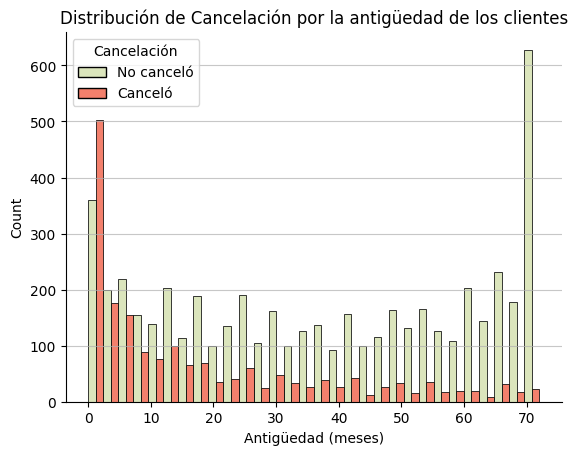

In [33]:
from ipywidgets import GridBox
colores_churn = ["#CFDDA6", "#EF553B"]

sns.histplot(
    data=data_plot,
    x="Antigüedad (meses)",
    hue="Cancelación",
    bins=30,
    multiple="dodge",
    palette = colores_churn
)
plt.title("Distribución de Cancelación por la antigüedad de los clientes");
plt.grid(axis='y', linestyle='-', alpha=0.7)
sns.despine()

#hay mas churn en menores tenures

In [34]:
data_plot.columns

Index(['Cancelación', 'Género', 'Cliente Adulto mayor', 'Cliente con pareja',
       'Cliente con dependientes', 'Antigüedad (meses)', 'Servicio telefónico',
       'Múltiples líneas', 'Servicio de internet', 'Seguridad en línea',
       'Respaldo en línea', 'Protección de dispositivo', 'Soporte técnico',
       'Streaming TV', 'Streaming películas', 'Tipo de contrato',
       'Facturación sin papel', 'Método de pago', 'Cargo mensual',
       'Cargo total', 'Cuentas diarias'],
      dtype='object')

In [35]:
fig = px.box(
    data_plot,
    x="Servicio de internet",
    y="Cargo mensual",
    color="Cancelación",
    color_discrete_map={
        "Canceló": "#EF553B",
        "No canceló": "#CFDDA6"
    }
)

fig.update_layout(
    title="Cancelación según cargo mensual por tipo de servicio de internet",
    xaxis_title="Tipo de servicio de internet",
    yaxis_title="Cargo mensual",
    title_x=0.5,
    plot_bgcolor='white'
)

fig.update_xaxes(showgrid=False, gridcolor='lightgray')
fig.update_yaxes(showgrid=True, gridcolor='lightgray')

fig.show()

In [36]:
data_plot.columns

Index(['Cancelación', 'Género', 'Cliente Adulto mayor', 'Cliente con pareja',
       'Cliente con dependientes', 'Antigüedad (meses)', 'Servicio telefónico',
       'Múltiples líneas', 'Servicio de internet', 'Seguridad en línea',
       'Respaldo en línea', 'Protección de dispositivo', 'Soporte técnico',
       'Streaming TV', 'Streaming películas', 'Tipo de contrato',
       'Facturación sin papel', 'Método de pago', 'Cargo mensual',
       'Cargo total', 'Cuentas diarias'],
      dtype='object')

/tmp/ipykernel_71271/1324474420.py:6: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



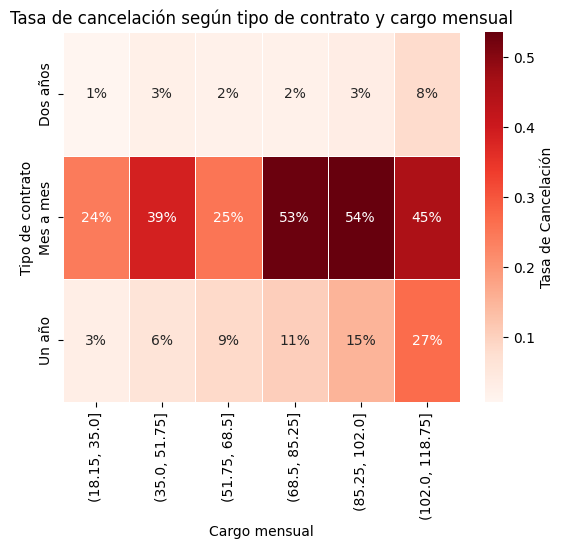

In [37]:
data_plot["Cargo_rango"] = pd.cut(
    data_plot["Cargo mensual"],
    bins=6
)

pivot = pd.pivot_table(
    data_plot,
    values="Cancelación",
    index="Tipo de contrato",
    columns="Cargo_rango",
    aggfunc=lambda x: (x == "Canceló").mean()
)

import seaborn as sns
import matplotlib.pyplot as plt

ax = sns.heatmap(
    pivot,
    annot=True,
    cmap="Reds",
    fmt=".0%",
    linewidths=.5
)

cbar = ax.collections[0].colorbar
cbar.set_label("Tasa de Cancelación")

plt.title("Tasa de cancelación según tipo de contrato y cargo mensual")
plt.xlabel("Cargo mensual")
plt.ylabel("Tipo de contrato")

plt.show()

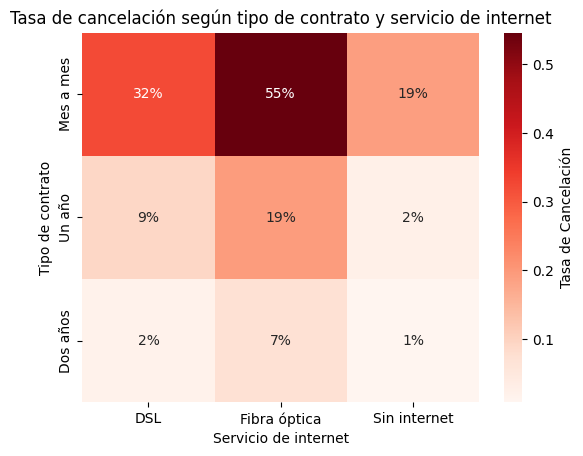

In [38]:
pivot = pd.pivot_table(
    data,
    values="Churn",
    index="Contract",
    columns="InternetService",
    aggfunc="mean"
)

# Rename index and columns for plotting based on translations
pivot.index = pivot.index.map(traducciones["Contract"])
pivot.columns = pivot.columns.map(traducciones["InternetService"])

ax = sns.heatmap(pivot, annot=True, cmap="Reds", fmt=".0%")
cbar = ax.collections[0].colorbar
cbar.set_label('Tasa de Cancelación')


plt.title("Tasa de cancelación según tipo de contrato y servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Tipo de contrato");

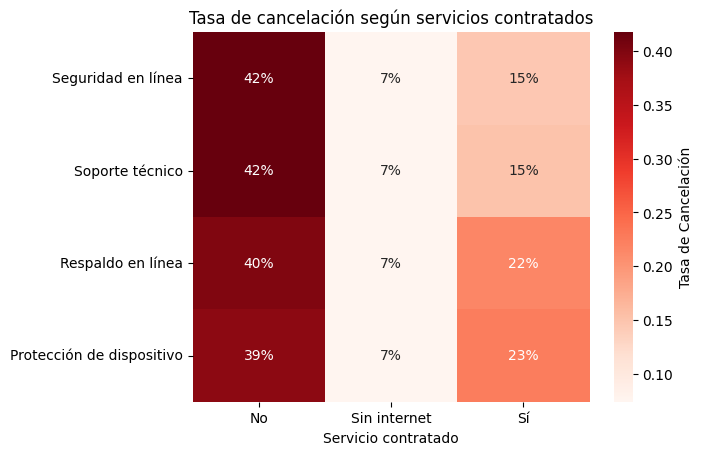

In [39]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

servicios = [
    "Seguridad en línea",
    "Soporte técnico",
    "Respaldo en línea",
    "Protección de dispositivo"
]

heatmap_data = []

for s in servicios:
    tabla = (
        data_plot.groupby(s)["Cancelación"]
        .apply(lambda x: (x == "Canceló").mean())
    )
    heatmap_data.append(tabla)

heatmap_df = pd.DataFrame(heatmap_data, index=servicios)

ax= sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".0%",
    cmap="Reds"
)
cbar = ax.collections[0].colorbar
cbar.set_label('Tasa de Cancelación')

plt.title("Tasa de cancelación según servicios contratados")
plt.xlabel("Servicio contratado")
plt.ylabel("")
plt.show()

#📄Informe final

Se evaluaron las características principales de la base de datos de Churn o Cancelación de clientes en la empresa. Se extrajeron las siguientes observaciones:


### Características de los clientes.

*  **Género:** tenemos una cantidad equilibrada de hombres y mujeres (alrededor de 50-50).
*  **Edad:** Solo el 16% de nuestros clientes son adultos mayores.
*   **Clientes con pareja:** tenemos una cantidad equilibrada de clientes con o sin pareja.
*   **Clientes con dependientes:** El 30% de nuestros clientes tienen dependientes.

De estas características, solo la edad pareció tener impacto en la cancelación de los servicios. Las personas fuera del grupo de edad de adulto mayor suelen tener una mayor permanencia.

### Cancelación por años de antiguedad.
Se identificó que la mayor tasa de cancelación ocurre en clientes de menor antiguedad. Esto recalca la importancia de los primeros meses para la permanencia.

Por otro lado, los clientes con mayor antiguedad tienden a tener muchos menos valores de cancelación. Recompensar a este tipo de clientes puede ser una buena estrategia para su permanencia.

### Cancelación por streaming.
No existe mucha diferencia de cancelación entre los que tienen o no contratados servicios de streaming tanto de películas como de TV, por tanto, no parece ser un servicio que representa relación directa con la cancelación.

### Cancelación por tipos de contrato.
Los contratos de mes a mes parecen promover una mayor tasa de cancelación, y esto se ve altamente reforzado cuando el precio a pagar es mayor (como en el sevicio de internet por fibra óptica).

### Cancelación por cargos.
Existe mayor cancelación cuando los cargos mensuales y las cuentas diarias son mayores. Por tanto, el servicio de internet de fibra óptica, que tiene cargos mensuales elevados, propicia mayor cancelación, especialmente cuando se paga mes a mes.

### Cancelación por métodos de pago.
El pago por cheque electrónico y la facturación por papel tienen mayores conteos de Cancelación. Esto podría deberse a un menor nivel de integración con los servicios digitales de la compañía o a una menor automatización del proceso de pago, factores que suelen asociarse con un menor compromiso del cliente y, por tanto, con una mayor probabilidad de abandono.

### Cancelación por servicios contratados.
Los clientes que no contratan servicios adicionales  de soporte tienen valores altos de cancelación.

### Resumen de sugerencias a implementar a partir de estos datos.
*  Ofrecer descuentos en los primeros meses de servicio.
*  Premiar la antiguedad de los clientes.
*  Invitar a los clientes a contratar servicios de soporte, y ofrecer descuentos para estos servicios los primeros meses.
*  Invitar a los clientes a realizar el pago de sus servicios con otros métodos.
*  Promover el contrato anual o de dos años.








